--- Processing AAPL ---
Calculated returns using Close column.


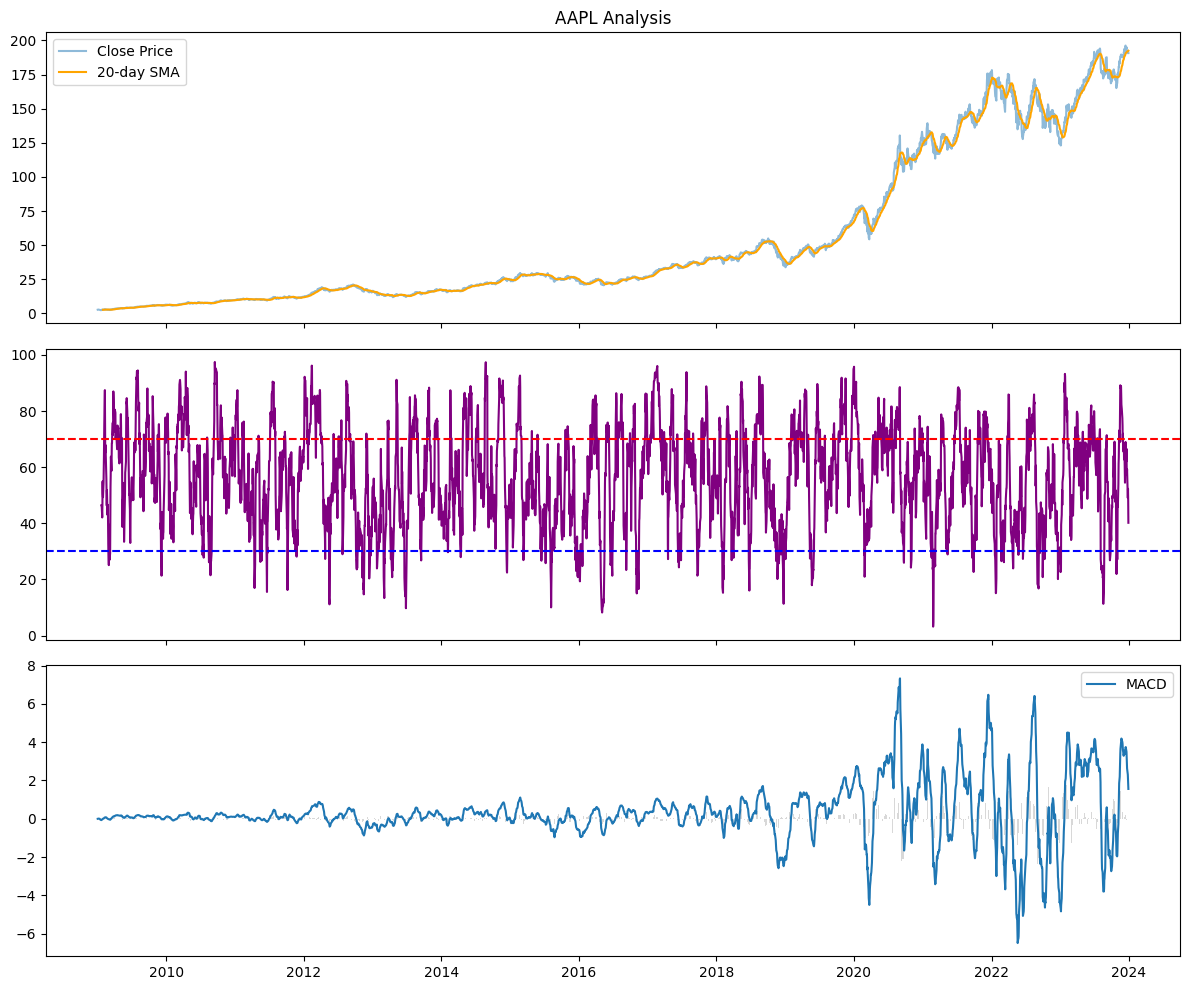

--- Processing AMZN ---
Calculated returns using Close column.


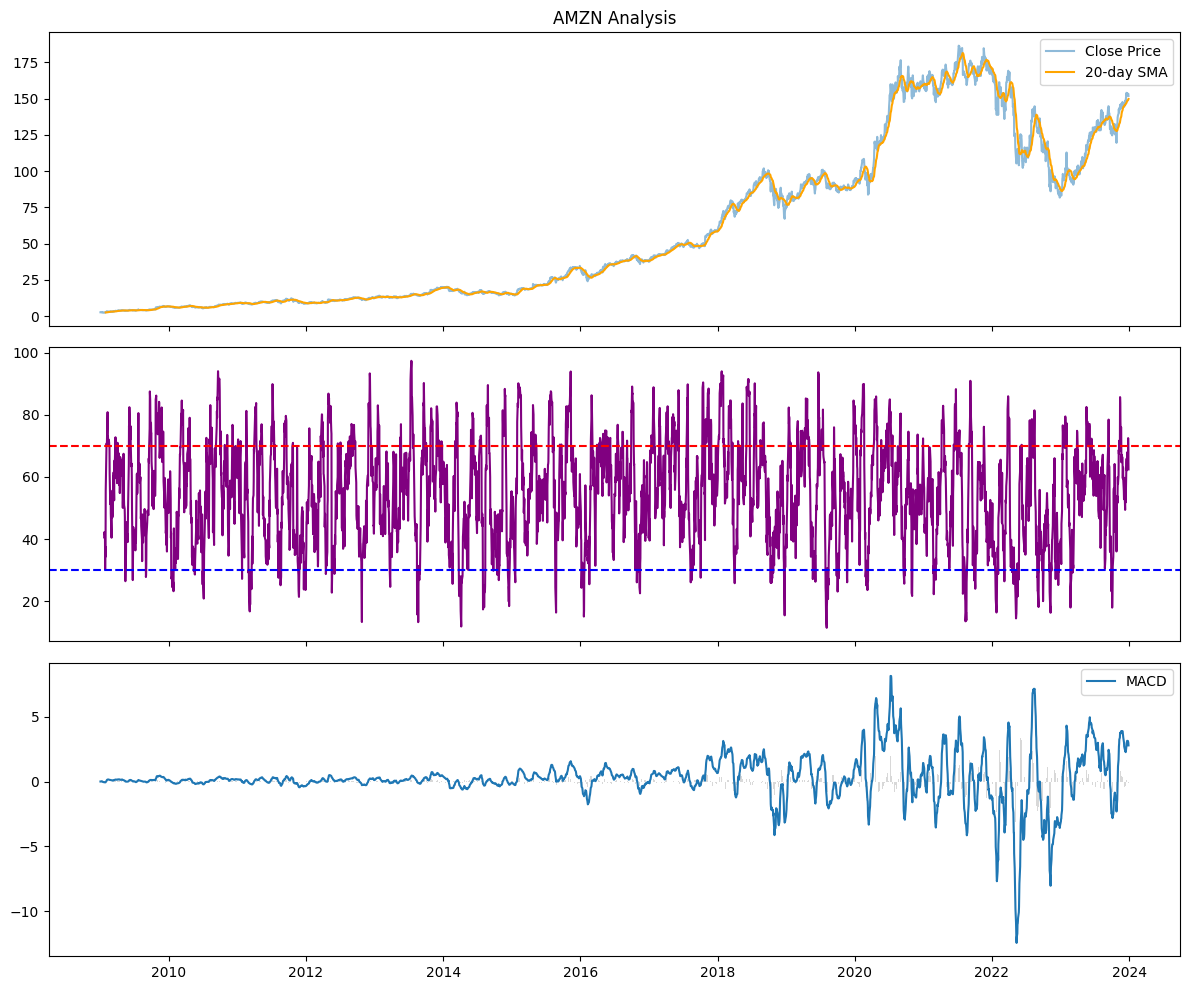

--- Processing GOOG ---
Calculated returns using Close column.


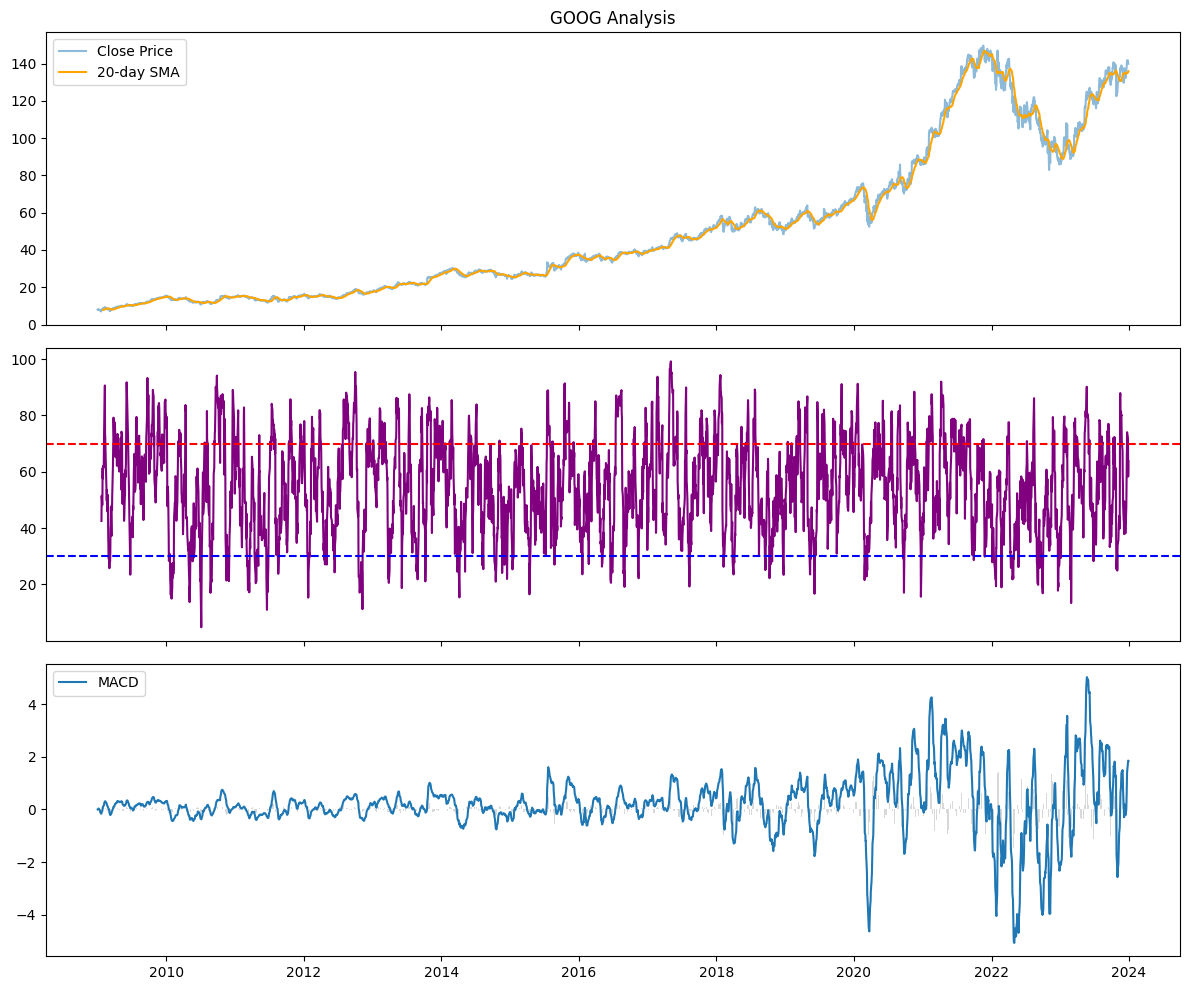

--- Processing META ---
Calculated returns using Close column.


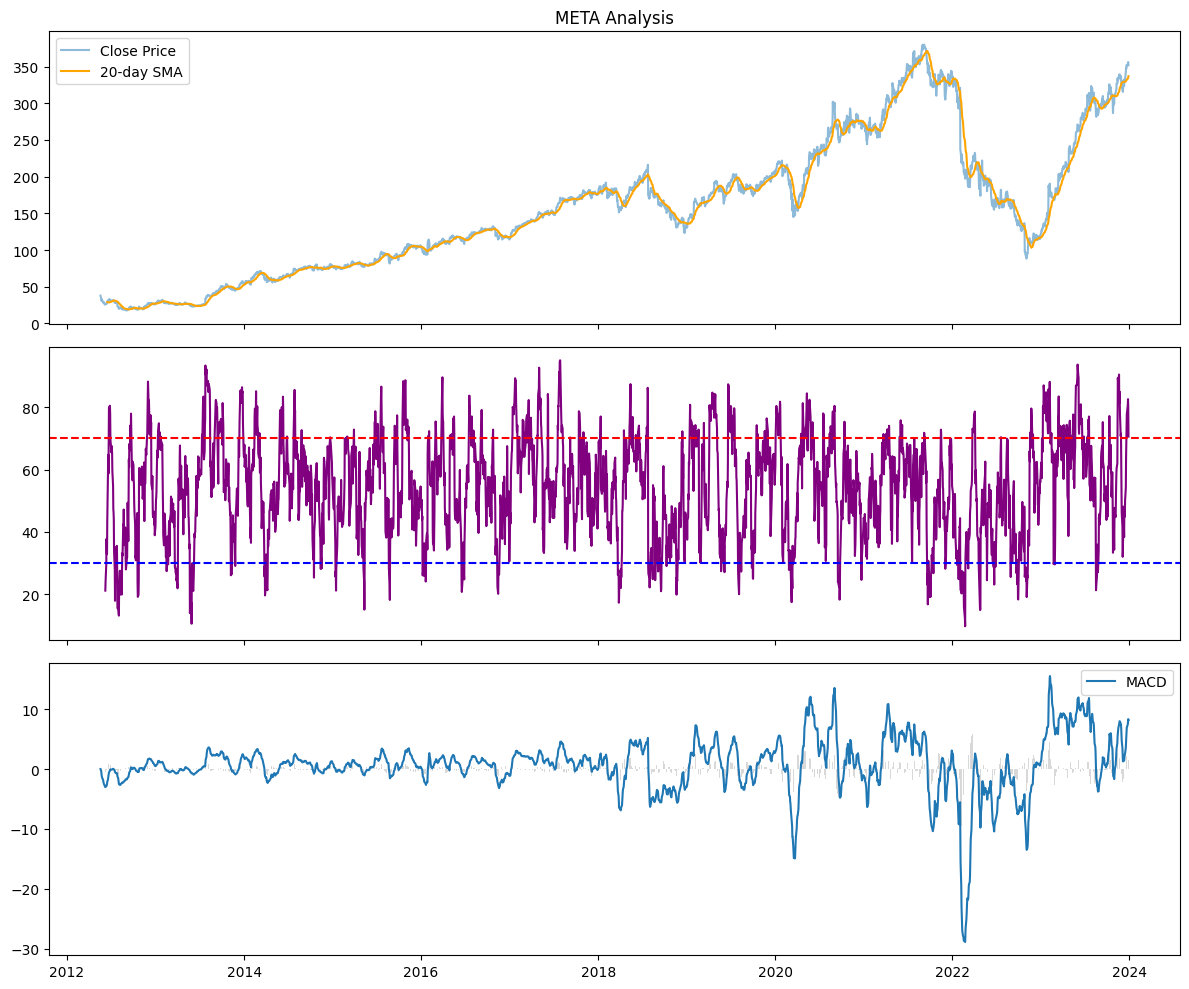

--- Processing NVDA ---
Calculated returns using Close column.


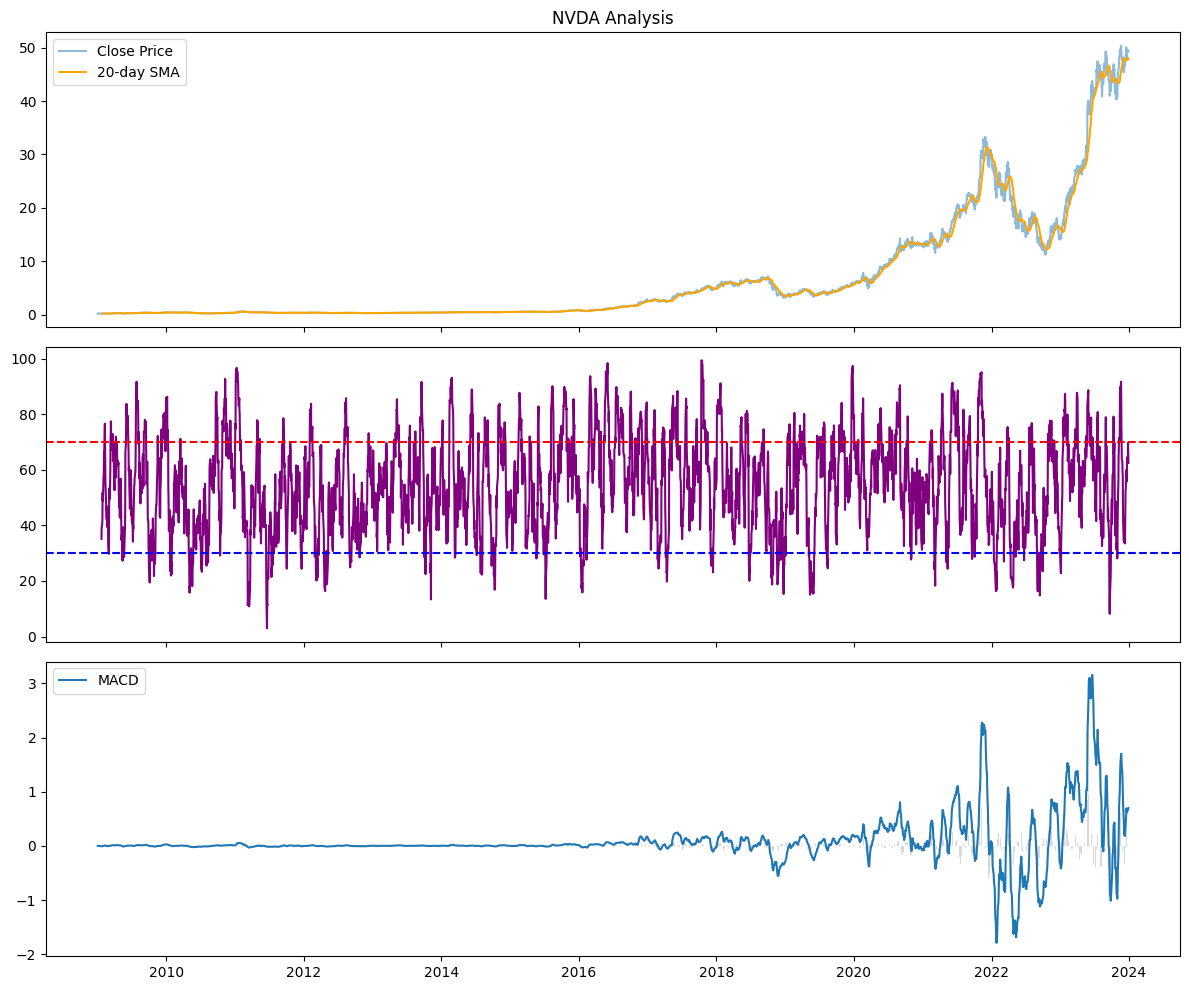

Success! All 5 stocks are processed and saved.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

data_path = '../data/raw/'
processed_path = '../data/processed/'
if not os.path.exists(processed_path):
    os.makedirs(processed_path)

stock_files = ['AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'NVDA.csv']

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

for file in stock_files:
    ticker = file.replace('.csv', '')
    print(f"--- Processing {ticker} ---")
    
    # Load
    df = pd.read_csv(os.path.join(data_path, file))
    
    # Clean Date
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').set_index('Date')
    
    # --- Technical Indicators ---
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
    df['RSI_14'] = calculate_rsi(df['Close'])
    
    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    
   
    return_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
    df['Daily_Return'] = df[return_col].pct_change()
    print(f"Calculated returns using {return_col} column.")
    
    # --- Visualization ---
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    ax1.plot(df['Close'], label='Close Price', alpha=0.5)
    ax1.plot(df['SMA_20'], label='20-day SMA', color='orange')
    ax1.set_title(f'{ticker} Analysis')
    ax1.legend()

    ax2.plot(df['RSI_14'], label='RSI', color='purple')
    ax2.axhline(70, color='red', linestyle='--')
    ax2.axhline(30, color='blue', linestyle='--')

    ax3.plot(df['MACD'], label='MACD')
    ax3.bar(df.index, df['MACD_Hist'], color='gray', alpha=0.3)
    ax3.legend()

    plt.tight_layout()
    plt.show()
    
    # Save processed data
    df.to_csv(os.path.join(processed_path, f'{ticker}_processed.csv'))

print("Success! All 5 stocks are processed and saved.")